In [1]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import random
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import lightning as pl
import torchmetrics
import comet_ml
import os
from lightning.pytorch import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from comet_ml import Experiment
import pandas as pd
import numpy as np
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from mediapipe_handcrop import MediapipeHandCrop
from tqdm import tqdm

2025-01-26 10:34:05.646711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737884045.665274 1792435 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737884045.670977 1792435 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-26 10:34:05.690297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## CUDA SETUP

In [2]:
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.set_default_dtype(torch.float32)
    else:
        device = torch.device('cpu')
        torch.set_default_dtype(torch.float32)
    return device

device = setup_device()
print(f"Using {device} device")

# Set random seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using cuda device


## CREATE TRAIN AND TEST CSV FILES

In [3]:
def average_brightness(image):
    # Convert to CSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # # Extracting brightness channel (V)
    brightness_channel = hsv_image[:, :, 2]

    average_brightness = np.mean(brightness_channel)
    if average_brightness > 50: 
        return True
    
    else: return False

In [8]:
train_pth = "./dataset/new_dataset/train"
test_pth = "./dataset/new_dataset/test"

import pandas as pd
import os
import json
from tqdm import tqdm
import cv2
import numpy as np
from PIL import Image

mediapipe_validator = MediapipeHandCrop(include_characteristic_vectors=True)

def validate_dataset_with_mediapipe(dataset_path, csv_file_path, new_dir):
    data = []
    classes_to_ignore = ["del", "nothing", "space"]
    index = 0

    for class_name in os.listdir(dataset_path):
        if class_name not in classes_to_ignore:
            # Create a directory for new validated class images
            new_class_path = os.path.join(new_dir, class_name)
            os.makedirs(new_class_path, exist_ok=True)

            class_index = ord(class_name) - 65
            count = 0

            for image_name in tqdm(os.listdir(os.path.join(dataset_path, class_name))):
                image_path = os.path.join(dataset_path, class_name, image_name)

                # Validate image with Mediapipe and brightness
                try:
                    result = mediapipe_validator(image_path)
                    if result is None:
                        continue
                    cropped_image, characteristic_vectors = result

                    # Check brightness and size
                    if average_brightness(np.array(cropped_image)) and cropped_image.size > (60, 60):
                        # Save the cropped image
                        new_image_path = os.path.join(new_class_path, image_name)
                        cropped_image = np.array(cropped_image)
                        cv2.imwrite(new_image_path, cropped_image)

                        # Append to the dataset
                        data.append({
                            "image_path": new_image_path,
                            "characteristic_vectors": json.dumps(characteristic_vectors),  # Serialize to JSON
                            "class_name": class_name,
                            "class_index": class_index,
                            "index": index
                        })
                        index += 1
                        count += 1

                except Exception as e:
                    print(f"Error processing {image_path}: {e}")
                    continue
                # break

            print(f"Saved {count} images from class {class_name}")

    # Save dataset to a CSV file
    df = pd.DataFrame(data)
    df.to_csv(csv_file_path, index=False)


I0000 00:00:1737884383.132991 1792435 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1737884383.172546 1795918 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 3080/PCIe/SSE2
W0000 00:00:1737884383.199190 1795896 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1737884383.222373 1795916 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [10]:
# # Create csv and dir
# validate_dataset_with_mediapipe(train_pth, 
#                                 csv_file_path = r"newest_dataset/validated_train_csv.csv",
#                                 new_dir = r"newest_dataset/validated_train")

In [11]:
# validate_dataset_with_mediapipe(test_pth, 
#                                 csv_file_path = r"newest_dataset/validated_test_csv.csv",
#                                 new_dir = r"newest_dataset/validated_test")

## DATASET

In [4]:
# import ast

# transform = transforms.Compose([
#     transforms.Resize((64,64)),
#     # transforms.CenterCrop((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
# ])

# class Dataset(Dataset):
#     def __init__(self, root_dir, csv_file, transform=None):
#         self.root_dir = root_dir
#         self.csv_file = csv_file
#         self.transform = transform
#         self.df = pd.read_csv(self.csv_file)
#         self.classes = sorted(np.unique(self.df["class_index"]))
#         self.class_names = sorted(np.unique(self.df["class_name"]))
        
#     def __len__(self):
#         dataset_len = len(self.df)
#         return dataset_len
    
#     def __getitem__(self, index):
#         if index >= len(self):
#             raise IndexError("Index out of bounds")
        
#         label = self.df.loc[index, "class_index"]
#         image_path = self.df.loc[index, "image_path"]
#         characteristic_vectors_str = self.df.loc[index, "characteristic_vectors"]

#         # Konwersja wektorów charakterystycznych
#         characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  
#         characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)

#         # Ładowanie obrazu
#         image = cv2.imread(image_path, cv2.IMREAD_COLOR)
#         if image is None:
#             raise FileNotFoundError(f"Image not found: {image_path}")
        
#         # Konwersja do RGB
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#         # Przekształcenia obrazu
#         if self.transform:
#             image = self.transform(Image.fromarray(image))

#         # Skalowanie wektorów
#         original_height, original_width = 64, 64  # Docelowe wymiary po transformacji
#         characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
#         characteristic_vectors[:, 1] *= (image.shape[1] / original_height)

#         return image, label, characteristic_vectors
        

In [24]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])


def parse_vectors(vector_str):
    # Remove all brackets and split by whitespace
    cleaned_str = vector_str.replace('[', '').replace(']', '')
    # Split into numbers and convert to float
    numbers = [float(x) for x in cleaned_str.split() if x.strip()]
    # Reshape into pairs (assuming each vector is 2D)
    return np.array(numbers).reshape(-1, 2)


class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))

    def __len__(self):
        dataset_len = len(self.df)
        return dataset_len
        
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        row = self.df.iloc[index]
        label = row["class_index"]
        
        # Fix path construction
        csv_path = row["image_path"]
        # Remove any existing prefix paths to get just the relative part (letter/filename)
        file_part = csv_path.split('/')[-2:]  # Gets ['F', 'F0011_test.jpg']
        image_path = os.path.join(self.root_dir, *file_part)
        
        characteristic_vectors = parse_vectors(row["characteristic_vectors"])
        
        # Load and process image
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(Image.fromarray(image))
            
        # Scale vectors
        original_height, original_width = 64, 64
        characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
        characteristic_vectors[:, 1] *= (image.shape[1] / original_height)
        
        return image, label, characteristic_vectors

In [25]:
# Train dataset and dataloader initialization
train_dataset = Dataset(root_dir="./newest_dataset/validated_train/",
                        csv_file= "./newest_dataset/validated_train_csv.csv",
                        transform=transform)

Dataset len:
26184

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


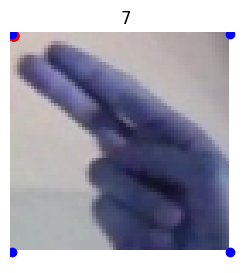

Characteristic vectors: 
[[0.58208269 0.62493485]
 [0.61492848 0.57440752]
 [0.59461546 0.51685309]
 [0.53478611 0.50389421]
 [0.48250389 0.50778615]
 [0.53829503 0.47036222]
 [0.47094011 0.40471175]
 [0.41683793 0.36766613]
 [0.37127402 0.3344484 ]
 [0.49225733 0.51174277]
 [0.42383173 0.44315663]
 [0.37463433 0.40306765]
 [0.3386606  0.3685506 ]
 [0.46698543 0.56512594]
 [0.43531531 0.54152393]
 [0.49791023 0.58312064]
 [0.54746723 0.61075157]
 [0.4588564  0.6247707 ]
 [0.43977201 0.60639161]
 [0.49229369 0.6327886 ]
 [0.53169322 0.65414894]]


In [26]:
# Sanity check
print("Dataset len:")
print(len(train_dataset))

print("\nDataset classes:")
print(train_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = train_dataset[random.randint(0, len(train_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [27]:
# Train dataset and dataloader initialization
test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
170

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


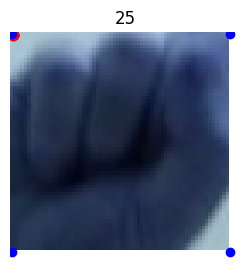

Characteristic vectors: 
[[0.37656331 0.55123723]
 [0.4435178  0.55700636]
 [0.5314554  0.50852096]
 [0.5608108  0.43786708]
 [0.5524115  0.37950024]
 [0.53947932 0.43628985]
 [0.56071007 0.38846931]
 [0.56630218 0.3742269 ]
 [0.56317174 0.37531039]
 [0.48001459 0.40899473]
 [0.51509362 0.3587842 ]
 [0.48976451 0.42772827]
 [0.47608793 0.47064042]
 [0.42171302 0.40192205]
 [0.4524914  0.36067906]
 [0.43142533 0.43715864]
 [0.41779801 0.47903496]
 [0.35868812 0.40759858]
 [0.38057482 0.38696268]
 [0.36993799 0.4462871 ]
 [0.36321092 0.47580653]]


In [28]:
# Sanity check
print("Dataset len:")
print(len(test_dataset))

print("\nDataset classes:")
print(test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = test_dataset[random.randint(0, len(test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  # Granice prostokąta

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)

## SPLITING DATA INTO TRAINING AND VALIDATION DATASETS

In [29]:
train_len = round(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_len, val_len, train_len + val_len == len(train_dataset)

(20947, 5237, True)

In [30]:
train_dataset_, val_dataset = random_split(train_dataset, [train_len, val_len])

In [31]:
# Sanity check once more

print(f"Number of training samples: {len(train_dataset_)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of train classes: {len(train_dataset_.dataset.classes)}")
print(f"Number of val classes: {len(val_dataset.dataset.classes)}")
print(f"Number of test samples: {len(test_dataset)}") 


Number of training samples: 20947
Number of validation samples: 5237
Number of train classes: 26
Number of val classes: 26
Number of test samples: 170


In [32]:
print(f"Train dataset classes: {train_dataset.classes}")
print(f"Validation dataset classes: {train_dataset.classes}")

Train dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Validation dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## DATALOADERS

In [33]:
import os
num_workers = os.cpu_count()
print(f"Suggested num_workers: {num_workers}")

Suggested num_workers: 32


In [34]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  # Use 'spawn' to safely initialize workers

train_dataloader = DataLoader(train_dataset_, 
                              batch_size=32, 
                              shuffle=True,
                              pin_memory=True)

val_dataloader = DataLoader(val_dataset,
                            batch_size=32,
                            shuffle=False,
                            pin_memory=True)

test_dataloader = DataLoader(test_dataset, 
                             batch_size=32, 
                             shuffle=False,
                             pin_memory=True)


In [35]:
# Sanity check
def loader_sanity_check(loader):
    for batch_idx, (data, labels, characteristic_vectors) in enumerate(loader):
        print(f"Batch nr: {batch_idx}")
        print(f"Batch size: {data.shape[0]}")
        print(f"Data shape: {data.shape}")
        print(f"Image shape: {data[0].shape}")
        print(f"Characteristic vectors shape: {len(characteristic_vectors)}")
        print(f"Characteristic vectors: {characteristic_vectors}")
        print(f"Classes: {labels}")
        print(f"Num classes: {len(labels)}")
        break

In [27]:
loader_sanity_check(train_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[49.7347, 64.7619],
         [60.4390, 51.9346],
         [62.5659, 32.7257],
         ...,
         [11.5949, 48.5856],
         [20.2919, 55.0631],
         [27.8830, 60.4392]],

        [[55.5777, 55.5056],
         [64.6466, 44.6321],
         [65.6644, 27.4384],
         ...,
         [14.7426, 26.4632],
         [ 6.6903, 20.0722],
         [ 0.4593, 14.6883]],

        [[33.1521, 64.9137],
         [42.1419, 57.6430],
         [44.8196, 45.6318],
         ...,
         [21.7162, 37.8653],
         [25.6153, 44.0508],
         [27.0782, 50.0656]],

        ...,

        [[24.9139, 64.2475],
         [42.7581, 53.9726],
         [56.4863, 33.9703],
         ...,
         [ 7.6526, 24.1294],
         [10.2053, 37.0565],
         [12.9956, 46.2990]],

        [[12.3524, 57.3314],
         [29.5941, 53.3248],
       

In [28]:
loader_sanity_check(val_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[36.4634, 64.1961],
         [28.4484, 59.4777],
         [25.3046, 48.6481],
         ...,
         [45.8976, 36.9146],
         [42.5650, 41.1631],
         [39.7497, 45.5458]],

        [[32.2286, 65.6383],
         [42.4070, 56.1283],
         [44.5094, 44.1125],
         ...,
         [20.8668, 37.5404],
         [23.9813, 43.8273],
         [25.7322, 49.8573]],

        [[57.9535, 59.7798],
         [65.3548, 46.1118],
         [64.3412, 27.2035],
         ...,
         [20.8075, 54.0292],
         [31.8102, 58.5609],
         [39.5575, 60.2829]],

        ...,

        [[ 2.9616, 59.7202],
         [19.1263, 64.0348],
         [34.0507, 53.5925],
         ...,
         [28.3303, 14.6060],
         [34.3532,  8.6517],
         [39.5879,  2.9231]],

        [[38.7747, 46.0718],
         [56.0613, 44.7954],
       

In [29]:
loader_sanity_check(test_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[ 7.1326, 62.4355],
         [28.6861, 60.4777],
         [49.9131, 45.6650],
         ...,
         [ 6.2890, 10.9291],
         [ 7.8201, 26.7674],
         [ 8.3716, 37.7560]],

        [[ 5.8576, 57.6342],
         [26.7703, 59.6616],
         [48.0776, 40.9094],
         ...,
         [ 7.2527, 10.1613],
         [ 6.5580, 26.1311],
         [ 5.7348, 36.1081]],

        [[ 5.8957, 60.1201],
         [27.1208, 59.0330],
         [47.5304, 42.6835],
         ...,
         [ 6.6615, 11.1107],
         [ 6.4246, 27.3819],
         [ 6.0614, 37.7908]],

        ...,

        [[26.5988, 64.1663],
         [36.5560, 59.6189],
         [43.4383, 47.9348],
         ...,
         [22.0566, 23.1919],
         [23.1683, 17.1042],
         [24.1680, 11.5004]],

        [[26.0426, 64.0471],
         [36.3126, 59.0488],
       

## COMET_ML SETUP

In [37]:
from comet_ml import Experiment
from utils2 import key

# Initialize Comet.ml experiment
experiment = Experiment(
    api_key=key,
    project_name="DLF-sign_letters_classification",
)

experiment.set_name("Multimodal model resnet")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/robb666/dlf-sign-letters-classification/b6fed65d8f8049e09c731cc8304d77d1



## Define helper functions to logs gradients and weights

In [38]:
def to_numpy(x):
    return x.detach().numpy()


def update_gradient_map(model, gradmap):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s/%s.%s" % ("gradient", name, "weight")
        bname = "%s/%s.%s" % ("gradient", name, "bias")

        gradmap.setdefault(wname, 0)
        gradmap.setdefault(bname, 0)

        gradmap[wname] += layer.weight.grad
        gradmap[bname] += layer.bias.grad

    return gradmap


def log_gradients(gradmap, step):
    for k, v in gradmap.items():
        experiment.log_histogram_3d(to_numpy(v), name=k, step=step)


def log_weights(model, step):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s.%s" % (name, "weight")
        bname = "%s.%s" % (name, "bias")

        experiment.log_histogram_3d(to_numpy(layer.weight), name=wname, step=step)
        experiment.log_histogram_3d(to_numpy(layer.bias), name=bname, step=step)

## MULTIMODAL MODEL

In [77]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultimodalModel(nn.Module):
    def __init__(self, num_classes, num_landmarks=21):
        super().__init__()
       
        # Image processing branch (ResNet50)
        self.base_model = models.resnet50(pretrained=True)
        self.base_model = nn.Sequential(*list(self.base_model.children())[:-1])
       
        # Freeze feature extractor
        for param in self.base_model.parameters():
            param.requires_grad = False
           
        # Image branch fully connected layers
        self.fc_image = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3)
        )
       
        # Landmark processing branch
        self.fc_landmarks = nn.Sequential(
            nn.Linear(num_landmarks * 2, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3)
        )
       
        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
       
    def forward(self, images, landmarks):
        # Process images through ResNet
        x = self.base_model(images)
        x = torch.flatten(x, 1)
        image_features = self.fc_image(x)
       
        # Process landmark features
        batch_size = landmarks.size(0)
        landmarks_flat = landmarks.view(batch_size, -1).float()
        landmark_features = self.fc_landmarks(landmarks_flat)
       
        # Combine features
        combined = torch.cat((image_features, landmark_features), dim=1)
       
        # Final classification
        output = self.classifier(combined)
        return output

In [66]:
num_classes = len(train_dataset_.dataset.classes)
model = MultimodalModel(num_classes=num_classes)
model.to(device)

MultimodalModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

## MODEL PARAMETERS

In [52]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"All parameters: {total_params}")
print(f"Frozen parameters: {frozen_params}")
print(f"Trainable parameters: {trainable_params}")


All parameters: 26443738
Frozen parameters: 23508032
Trainable parameters: 2935706


In [53]:
learning_rate = 0.0001
batch_size = 32
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # https://paperswithcode.com/method/weight-decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3) # https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
num_epochs = 15
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

hyper_params = {"batch_size": batch_size, "num_epochs": num_epochs, "learning_rate": learning_rate}
# experiment.log_parameters(hyper_params)

In [54]:
def train_model(device, model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, resume_path=None, early_stopping_patience=5):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')  
    # epochs_no_improve = 0

    # Load checkpoint if provided
    start_epoch = 0
    if resume_path:
        checkpoint = torch.load(resume_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.to(device)
    print(f"Starting Training")

    for epoch in range(start_epoch, num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        gradmap = {}

        for batch_idx, (images, labels, characteristic_vectors) in enumerate(train_loader):
            # Convert characteristic vectors to tensor
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device) 

            optimizer.zero_grad()
            outputs = model(images, characteristic_vectors)  # Pass both images and characteristic vectors

            loss = criterion(outputs, labels)
            loss.backward()

            # Update gradient map
            gradmap = update_gradient_map(model, gradmap)

            optimizer.step()

            # Accumulate batch loss
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Log every 100 batches
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch + 1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
                experiment.log_metric("train_loss", loss.item(), step=epoch * len(train_loader) + batch_idx)

        # Log gradients
        log_gradients(gradmap, epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader.dataset)  # Average loss per sample
        train_accuracy = 100. * train_correct / train_total
        train_losses.append(epoch_loss)

        # Log epoch metrics
        experiment.log_metric("epoch_train_loss", epoch_loss, step=epoch)
        experiment.log_metric("epoch_train_accuracy", train_accuracy, step=epoch)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        print("Validating...")
        with torch.inference_mode():
            for images, labels, characteristic_vectors in val_loader:
                images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)
                outputs = model(images, characteristic_vectors)  
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader.dataset)  # Average loss per sample
        val_accuracy = 100. * val_correct / val_total
        val_losses.append(val_epoch_loss)

        print(f'Epoch [{epoch + 1}/{num_epochs}]')
        print(f'Training Loss: {epoch_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print('-' * 60)

        # Log validation metrics
        experiment.log_metric("val_loss", val_epoch_loss, step=epoch)
        experiment.log_metric("val_accuracy", val_accuracy, step=epoch)

        # Adjust learning rate using scheduler
        scheduler.step(val_epoch_loss)

        # Log weights
        log_weights(model, epoch)

        # Save best model checkpoint
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_epoch = epoch
            epochs_no_improve = 0

            best_checkpoint_path = f"./models/multimodal_model/checkpoints/best_model.pt"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, best_checkpoint_path)

            print(f"Best model updated and saved at: {best_checkpoint_path}")
        else:
            epochs_no_improve += 1

        # Early stopping check
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered. No improvement in validation loss for {early_stopping_patience} consecutive epochs.")
            break

        # Save model checkpoint
        checkpoint_path = f"./models/multimodal_model/checkpoints/Epoch {epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, checkpoint_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

        model_path = f"./models/multimodal_model/checkpoints/model epoch {epoch+1}"
        weights_path = f"./models/multimodal_model/checkpoints/model weights epoch {epoch+1}"

        torch.save(model, model_path)
        torch.save(model.state_dict(), weights_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

    return train_losses, val_losses


In [79]:
# Test loop
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
    
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            images = images.float().to(device)
            labels = labels.to(device)
            characteristic_vectors = characteristic_vectors.float().to(device)

            # images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)
            outputs = model(images, characteristic_vectors)  # Pass both images and characteristic vectors
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    # # Log test metrics
    # experiment.log_metric("test_loss", test_loss)
    # experiment.log_metric("test_accuracy", test_accuracy)

    return test_loss, test_accuracy


## TRAINING

In [57]:
# train_losses, val_losses = train_model(device, model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs, scheduler)

In [58]:
# Saving model and weights
torch.save(model, "./models/multimodal_model/multimodal_model")
torch.save(model.state_dict(), "./models/multimodal_model/multimodal_model_weights")

## Log the Model to Comet

In [44]:
from comet_ml.integration.pytorch import log_model

log_model(experiment, model, "multimodal model")

## End Experiment

In [76]:
experiment.end()

COMET INFO: The process of logging environment details (conda environment, git patch) is underway. Please be patient as this may take some time.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Multimodal model
COMET INFO:     url                   : https://www.comet.com/ziemmi13/dlf-sign-letters-classification/b8eb3ea57ff44ea497d1ee6e5741a836
COMET INFO:   Metrics:
COMET INFO:     train_loss : 3.423539638519287
COMET INFO:   Others:
COMET INFO:     Name : Multimodal model
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (125.13 KB)
COMET INFO:  

## TESTING

In [83]:
test_loss, test_accuracy = test_model(device, model, test_dataloader, criterion)

# TESTING ON A DIFFERENT DATASET

In [95]:
# model = torch.load(f="./models/multimodal_model/multimodal_model", weights_only=False)
# model.to(device)


num_classes = len(train_dataset_.dataset.classes)

model = MultimodalModel(num_classes)
checkpoint = torch.load("./wetransfer/multi/best_model")
# checkpoint = torch.load("./wetransfer/multi/model epoch 15")
model.load_state_dict(checkpoint['model_state_dict'])

# model = torch.load(f="./wetransfer/multi/best_model.pt", weights_only=False)
model.to(device)

/tmp/ipykernel_1792435/2856662616.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./wetransfer/multi/best_model")


IsADirectoryError: [Errno 21] Is a directory: './wetransfer/multi/best_model'

In [93]:
import torch
import os

def custom_persistent_load(pid):
    return pid

# Initialize model first
num_classes = len(train_dataset_.dataset.classes)
model = MultimodalModel(num_classes)

try:
    # Try loading with custom persistent loader
    import pickle
    with open("./wetransfer/multi/best_model/data.pkl", 'rb') as f:
        state_dict = pickle.load(f, persistent_load=custom_persistent_load)
    
    # If it's a dictionary with model state
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
    else:
        # If it's just the state dict directly
        model.load_state_dict(state_dict)
    
    print("Model loaded successfully")
except Exception as e:
    print(f"Failed to load model: {str(e)}")

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Failed to load model: 'persistent_load' is an invalid keyword argument for load()


MultimodalModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

In [71]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])


def parse_vectors(vector_str):
    cleaned_str = vector_str.replace('[', '').replace(']', '')
    numbers = [float(x) for x in cleaned_str.split() if x.strip()]
    return np.array(numbers).reshape(-1, 2)


class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))
        
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        row = self.df.iloc[index]
        label = row["class_index"]
        
        # Fix path construction
        csv_path = row["image_path"]
        # Remove any existing prefix paths to get just the relative part (letter/filename)
        file_part = csv_path.split('/')[-2:]  # Gets ['F', 'F0011_test.jpg']
        image_path = os.path.join(self.root_dir, *file_part)
        
        characteristic_vectors = parse_vectors(row["characteristic_vectors"])
        
        # Load and process image
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(Image.fromarray(image))
            
        # Scale vectors
        original_height, original_width = 64, 64
        characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
        characteristic_vectors[:, 1] *= (image.shape[1] / original_height)
        
        return image, label, characteristic_vectors

In [72]:
# Train dataset and dataloader initialization
validated_test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
170

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:


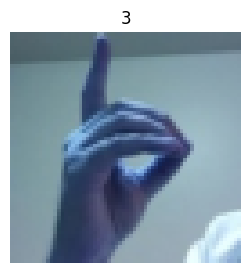

Characteristic vectors: 
[[0.47762007 0.83067191]
 [0.57584757 0.74664766]
 [0.62933791 0.6527583 ]
 [0.68433201 0.59136319]
 [0.74003887 0.54231167]
 [0.47523451 0.50773829]
 [0.49613729 0.38549441]
 [0.51093709 0.30697757]
 [0.52417958 0.24475133]
 [0.44169348 0.52194071]
 [0.5770846  0.42529631]
 [0.66723573 0.45637524]
 [0.71475828 0.50336528]
 [0.43295157 0.55567724]
 [0.56563407 0.46436667]
 [0.65782315 0.49165359]
 [0.70827079 0.53316522]
 [0.44909349 0.60182935]
 [0.54658705 0.52178216]
 [0.6249314  0.51099145]
 [0.67905784 0.51951963]]


In [74]:
# Sanity check
print("Dataset len:")
print(len(validated_test_dataset))

print("\nDataset classes:")
print(validated_test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = validated_test_dataset[random.randint(0, len(validated_test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [80]:
validated_test_dataset_loader = DataLoader(validated_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)


In [90]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = test_model(device, model, validated_test_dataset_loader, criterion)

Test Loss: 0.1201, Test Accuracy: 1.76%
